# Movielens 데이터 분석

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 처음부터 복습하기

# 데이터 준비

In [154]:
# 데이터 파일들의 경로
movies_file='https://github.com/wesm/pydata-book/raw/refs/heads/3rd-edition/datasets/movielens/movies.dat'
ratings_file='https://github.com/wesm/pydata-book/raw/refs/heads/3rd-edition/datasets/movielens/ratings.dat'
users_file='https://github.com/wesm/pydata-book/raw/refs/heads/3rd-edition/datasets/movielens/users.dat'

In [155]:
# 데이터프레임 컬럼 이름들
movies_col=['movie_id','title','genres'] # movies.dat 파일에서 사용할 컬럼 이름들.
ratings_col=['user_id','movie_id','rating','timestamp'] # rating.dat 파일의 컬럼 이름들.
users_col=['user_id','gender','age','occupation','zip_code'] # users.dat 파일의 컬럼 이름들.

# 데이터프레임 생성

* movies
* ratings
* users
* 데이터프레임 합치기(merge)
    *   ratings와 movies를 merge
    *   위의 결과와 users를 merge

## movies DataFrame

In [156]:
mfdf=pd.read_csv(movies_file,names=movies_col,sep='::',engine='python')

In [5]:
mfdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3883 entries, 0 to 3882
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   movie_id  3883 non-null   int64 
 1   title     3883 non-null   object
 2   genres    3883 non-null   object
dtypes: int64(1), object(2)
memory usage: 91.1+ KB


## ratings DataFrame

In [6]:
rfdf=pd.read_csv(ratings_file,names=ratings_col,engine='python',sep='::')

In [7]:
rfdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   user_id    1000209 non-null  int64
 1   movie_id   1000209 non-null  int64
 2   rating     1000209 non-null  int64
 3   timestamp  1000209 non-null  int64
dtypes: int64(4)
memory usage: 30.5 MB


In [8]:
# timestamp(정수) -- > 날짜 타입(datetime) 변환= to_  타임스탬프 문서확인이 필요하다
pd.to_datetime(rfdf.timestamp,unit='s') # unit: 's', 'ms', 'ns' 1/1, 1/1000, 1/1000000

,timestamp
0,2000-12-31 22:12:40
1,2000-12-31 22:35:09
2,2000-12-31 22:32:48
3,2000-12-31 22:04:35
4,2001-01-06 23:38:11
...,...
1000204,2000-04-26 02:35:41
1000205,2000-04-25 23:21:27
1000206,2000-04-25 23:19:06
1000207,2000-04-26 02:20:48


users DataFrame

In [9]:
ufdf=pd.read_csv(users_file,names=users_col,engine='python',sep='::') #sep가 한글자이상이면 engine이필요하다

In [10]:
ufdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6040 entries, 0 to 6039
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     6040 non-null   int64 
 1   gender      6040 non-null   object
 2   age         6040 non-null   int64 
 3   occupation  6040 non-null   int64 
 4   zip_code    6040 non-null   object
dtypes: int64(3), object(2)
memory usage: 236.1+ KB


In [11]:
# mfdf
# rfdf
ufdf

,user_id,gender,age,occupation,zip_code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455
...,...,...,...,...,...
6035,6036,F,25,15,32603
6036,6037,F,45,1,76006
6037,6038,F,56,1,14706
6038,6039,F,45,0,01060


## DataFrame merge(조인)

In [12]:
# rfdf와 mfdf를 merge(inner join)
df=pd.merge(left=rfdf,right=mfdf)

In [13]:
df.head()

,user_id,movie_id,rating,timestamp,title,genres
0,1,1193,5,978300760,One Flew Over the Cuckoo's Nest (1975),Drama
1,1,661,3,978302109,James and the Giant Peach (1996),Animation|Children's|Musical
2,1,914,3,978301968,My Fair Lady (1964),Musical|Romance
3,1,3408,4,978300275,Erin Brockovich (2000),Drama
4,1,2355,5,978824291,"Bug's Life, A (1998)",Animation|Children's|Comedy


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 6 columns):
 #   Column     Non-Null Count    Dtype 
---  ------     --------------    ----- 
 0   user_id    1000209 non-null  int64 
 1   movie_id   1000209 non-null  int64 
 2   rating     1000209 non-null  int64 
 3   timestamp  1000209 non-null  int64 
 4   title      1000209 non-null  object
 5   genres     1000209 non-null  object
dtypes: int64(4), object(2)
memory usage: 45.8+ MB


In [15]:
# df와 users를 merge(inner join)
df=pd.merge(left=df,right=ufdf)
df

,user_id,movie_id,rating,timestamp,title,genres,gender,age,occupation,zip_code
0,1,1193,5,978300760,One Flew Over the Cuckoo's Nest (1975),Drama,F,1,10,48067
1,1,661,3,978302109,James and the Giant Peach (1996),Animation|Children's|Musical,F,1,10,48067
2,1,914,3,978301968,My Fair Lady (1964),Musical|Romance,F,1,10,48067
3,1,3408,4,978300275,Erin Brockovich (2000),Drama,F,1,10,48067
4,1,2355,5,978824291,"Bug's Life, A (1998)",Animation|Children's|Comedy,F,1,10,48067
...,...,...,...,...,...,...,...,...,...,...
1000204,6040,1091,1,956716541,Weekend at Bernie's (1989),Comedy,M,25,6,11106
1000205,6040,1094,5,956704887,"Crying Game, The (1992)",Drama|Romance|War,M,25,6,11106
1000206,6040,562,5,956704746,Welcome to the Dollhouse (1995),Comedy|Drama,M,25,6,11106
1000207,6040,1096,4,956715648,Sophie's Choice (1982),Drama,M,25,6,11106


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 10 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   user_id     1000209 non-null  int64 
 1   movie_id    1000209 non-null  int64 
 2   rating      1000209 non-null  int64 
 3   timestamp   1000209 non-null  int64 
 4   title       1000209 non-null  object
 5   genres      1000209 non-null  object
 6   gender      1000209 non-null  object
 7   age         1000209 non-null  int64 
 8   occupation  1000209 non-null  int64 
 9   zip_code    1000209 non-null  object
dtypes: int64(6), object(4)
memory usage: 76.3+ MB


# 데이터 탐색

*   카테고리 변수 탐색
    * 성별 빈도수
    * 연령대 빈도수
    * 직업군 빈도수
    * 별점 빈도수

In [17]:
df.gender.value_counts()


,count
gender,
M,753769
F,246440


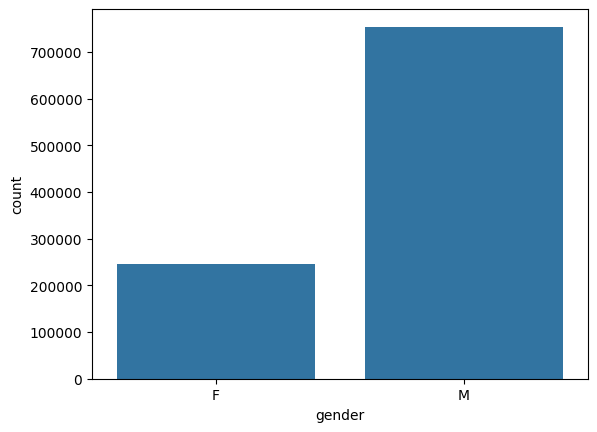

In [18]:
sns.countplot(data=df,x='gender')
plt.show()

In [19]:
df.age.value_counts()


,count
age,
25,395556
35,199003
18,183536
45,83633
50,72490
56,38780
1,27211


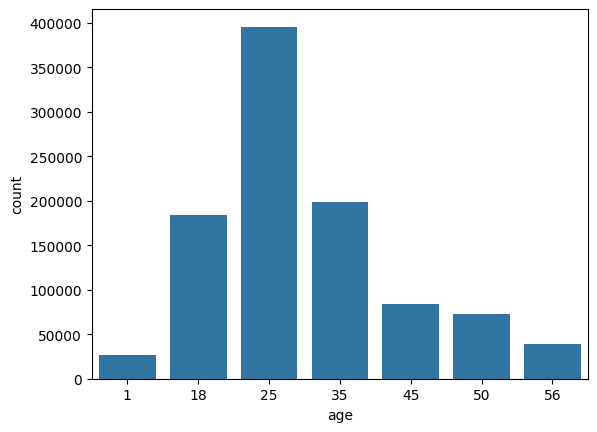

In [20]:
sns.countplot(data=df, x='age')
plt.show()

In [21]:
df.occupation.value_counts()

,count
occupation,
4,131032
0,130499
7,105425
1,85351
17,72816
20,60397
12,57214
2,50068
14,49109


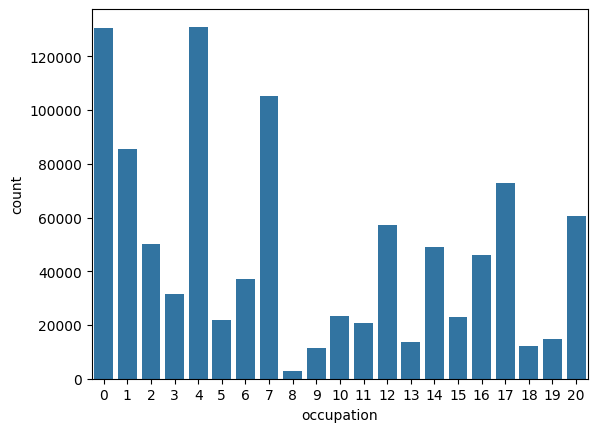

In [22]:
sns.countplot(data=df,x='occupation')
plt.show()

In [23]:
df.rating.value_counts()

,count
rating,
4,348971
3,261197
5,226310
2,107557
1,56174


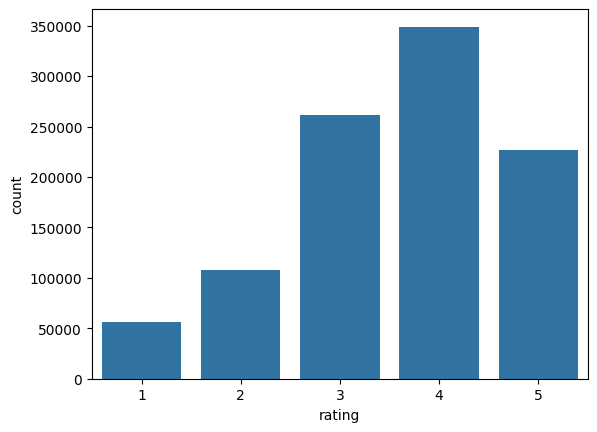

In [24]:
sns.countplot(data=df,x='rating')
plt.show()

# 데이터 분석

## 별점 평균 상위10개/하위10개 영화 제목

영화 제목별 별점 평균을 계산하고 정렬

In [31]:
# rating_mean=df.groupby(by='title',observed=True).rating.mean()
# rating_mean
by_title=df.groupby(by='title',observed=True).rating.mean()
by_title

,rating
title,
"$1,000,000 Duck (1971)",3.027027
'Night Mother (1986),3.371429
'Til There Was You (1997),2.692308
"'burbs, The (1989)",2.910891
...And Justice for All (1979),3.713568
...,...
"Zed & Two Noughts, A (1985)",3.413793
Zero Effect (1998),3.750831
Zero Kelvin (Kjærlighetens kjøtere) (1995),3.500000


In [215]:
by_titlestd=df.groupby(by='title',observed=True).rating.std()
by_titlestd.index

Index(['$1,000,000 Duck (1971)', ''Night Mother (1986)',
       ''Til There Was You (1997)', ''burbs, The (1989)',
       '...And Justice for All (1979)', '1-900 (1994)',
       '10 Things I Hate About You (1999)', '101 Dalmatians (1961)',
       '101 Dalmatians (1996)', '12 Angry Men (1957)',
       ...
       'Young Poisoner's Handbook, The (1995)', 'Young Sherlock Holmes (1985)',
       'Young and Innocent (1937)', 'Your Friends and Neighbors (1998)',
       'Zachariah (1971)', 'Zed & Two Noughts, A (1985)', 'Zero Effect (1998)',
       'Zero Kelvin (Kjærlighetens kjøtere) (1995)', 'Zeus and Roxanne (1997)',
       'eXistenZ (1999)'],
      dtype='object', name='title', length=3706)

In [33]:
by_title.index

Index(['$1,000,000 Duck (1971)', ''Night Mother (1986)',
       ''Til There Was You (1997)', ''burbs, The (1989)',
       '...And Justice for All (1979)', '1-900 (1994)',
       '10 Things I Hate About You (1999)', '101 Dalmatians (1961)',
       '101 Dalmatians (1996)', '12 Angry Men (1957)',
       ...
       'Young Poisoner's Handbook, The (1995)', 'Young Sherlock Holmes (1985)',
       'Young and Innocent (1937)', 'Your Friends and Neighbors (1998)',
       'Zachariah (1971)', 'Zed & Two Noughts, A (1985)', 'Zero Effect (1998)',
       'Zero Kelvin (Kjærlighetens kjøtere) (1995)', 'Zeus and Roxanne (1997)',
       'eXistenZ (1999)'],
      dtype='object', name='title', length=3706)

In [34]:
by_title.values

array([3.02702703, 3.37142857, 2.69230769, ..., 3.5       , 2.52173913,
       3.25609756])

In [35]:
# top10=rating_mean.sort_values(ascending=False).head(n=14)
# top10
by_title_sorted=by_title.sort_values(ascending=False)
by_title_sorted

,rating
title,
Lured (1947),5.0
Ulysses (Ulisse) (1954),5.0
"Baby, The (1973)",5.0
Follow the Bitch (1998),5.0
Schlafes Bruder (Brother of Sleep) (1995),5.0
...,...
Terror in a Texas Town (1958),1.0
White Boys (1999),1.0
Mutters Courage (1995),1.0


In [38]:
# by_title_sorted.head(n=10)
by_title_sorted.tail(n=10)

,rating
title,
Sleepover (1995),1.0
"Loves of Carmen, The (1948)",1.0
Santa with Muscles (1996),1.0
"McCullochs, The (1975)",1.0
"Silence of the Palace, The (Saimt el Qusur) (1994)",1.0
Terror in a Texas Town (1958),1.0
White Boys (1999),1.0
Mutters Courage (1995),1.0
Shadows (Cienie) (1988),1.0


In [37]:
df[df.title=='Lured (1947)']

,user_id,movie_id,rating,timestamp,title,genres,gender,age,occupation,zip_code
879590,5313,3656,5,960920392,Lured (1947),Crime,M,56,0,55406


In [39]:
df[df.title=='Wirey Spindell (1999)']

,user_id,movie_id,rating,timestamp,title,genres,gender,age,occupation,zip_code
201369,1242,3228,1,987709390,Wirey Spindell (1999),Comedy,F,35,0,10014
752758,4486,3228,1,965013093,Wirey Spindell (1999),Comedy,M,35,8,98674


별점 리뷰 건수가 1~2개 밖에 없는 영화들의 별점 평균은 큰 의미가 없다. 일정 개수 이상의 별점 리뷰가 있는 영화들을 선택해서 별점 평균을 분석하는 것이 의미가 있음.

In [212]:
# titlestd=by_titlestd.value_counts()
# titlestd.describe()

,count
count,3323.000000
mean,1.080951
std,1.001688
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,33.000000


In [42]:
title_count=df.title.value_counts() # 영화제목빈도수
title_count.describe() # 영화제목빈도수 기술통계량

,count
count,3706.000000
mean,269.889099
std,384.047838
min,1.000000
25%,33.000000
50%,123.500000
75%,350.000000
max,3428.000000


## 별점 리뷰 횟수가 120회 이상인 영화들을 선택해서 분석(중앙값)

In [210]:
stdind=titlestd[titlestd>=120].index
stdind

Index([], dtype='float64', name='rating')

In [213]:
title_count

,count
title,
American Beauty (1999),3428
Star Wars: Episode IV - A New Hope (1977),2991
Star Wars: Episode V - The Empire Strikes Back (1980),2990
Star Wars: Episode VI - Return of the Jedi (1983),2883
Jurassic Park (1993),2672
...,...
Aiqing wansui (1994),1
Broken Vessels (1998),1
White Boys (1999),1


In [223]:
title_count[title_count>=120]

,count
title,
American Beauty (1999),3428
Star Wars: Episode IV - A New Hope (1977),2991
Star Wars: Episode V - The Empire Strikes Back (1980),2990
Star Wars: Episode VI - Return of the Jedi (1983),2883
Jurassic Park (1993),2672
...,...
Blue Hawaii (1961),121
Backbeat (1993),120
Kazaam (1996),120


In [45]:
# 별점 리뷰 횟수가 120회 이상인 영화 제목들
# title_count[title_count>=120]
indexer=title_count[title_count>=120].index# 인덱스와 밸류중 인덱스선택
indexer

Index(['American Beauty (1999)', 'Star Wars: Episode IV - A New Hope (1977)',
       'Star Wars: Episode V - The Empire Strikes Back (1980)',
       'Star Wars: Episode VI - Return of the Jedi (1983)',
       'Jurassic Park (1993)', 'Saving Private Ryan (1998)',
       'Terminator 2: Judgment Day (1991)', 'Matrix, The (1999)',
       'Back to the Future (1985)', 'Silence of the Lambs, The (1991)',
       ...
       'Harriet the Spy (1996)', 'Dudley Do-Right (1999)',
       'Paris, Texas (1984)', 'Extreme Measures (1996)',
       'My Fellow Americans (1996)', 'Blue Hawaii (1961)', 'Backbeat (1993)',
       'Kazaam (1996)', 'Communion (1989)', 'Bed of Roses (1996)'],
      dtype='object', name='title', length=1879)

In [209]:
stdind.loc[stdind]

AttributeError: 'Index' object has no attribute 'loc'

In [216]:
by_titlestd.loc[indexer]

,rating
title,
American Beauty (1999),0.975133
Star Wars: Episode IV - A New Hope (1977),0.800781
Star Wars: Episode V - The Empire Strikes Back (1980),0.844432
Star Wars: Episode VI - Return of the Jedi (1983),0.927356
Jurassic Park (1993),0.969777
...,...
Blue Hawaii (1961),1.038249
Backbeat (1993),0.952330
Kazaam (1996),0.798458


In [46]:
by_title.loc[indexer]# by_title: 타이틀 별점평균

,rating
title,
American Beauty (1999),4.317386
Star Wars: Episode IV - A New Hope (1977),4.453694
Star Wars: Episode V - The Empire Strikes Back (1980),4.292977
Star Wars: Episode VI - Return of the Jedi (1983),4.022893
Jurassic Park (1993),3.763847
...,...
Blue Hawaii (1961),2.826446
Backbeat (1993),3.525000
Kazaam (1996),1.466667


In [217]:
by_titlestdd=by_titlestd.loc[indexer].sort_values(ascending=False)

In [202]:
# 별점 리뷰 횟수가 120회 이상인 영화들의 별점 평균을 내림차순 정렬
by_title_sorted=by_title.loc[indexer].sort_values(ascending=False)

In [204]:
by_title_sorted.head(n=10)
# by_title_sorted

0.5702804389197473

In [49]:
by_title_sorted.tail(n=10)

,rating
title,
Iron Eagle II (1988),1.864865
Jaws 3-D (1983),1.852381
"Flintstones in Viva Rock Vegas, The (2000)",1.804688
Stop! Or My Mom Will Shoot (1992),1.782123
Police Academy 5: Assignment: Miami Beach (1988),1.766667
Baby Geniuses (1999),1.701220
Police Academy 6: City Under Siege (1989),1.657718
Aces: Iron Eagle III (1992),1.640000
Battlefield Earth (2000),1.611111


## 성별에 따른 영화 선호도

*   별점 리뷰 횟수가 120번 이상인 영화들 선택.
*   제목별 성별 별점 평균 상위/하위10개.

In [221]:
df[df.title.isin(by_titlestdd)]

,user_id,movie_id,rating,timestamp,title,genres,gender,age,occupation,zip_code


In [107]:
df[df.title.isin(indexer)]

,user_id,movie_id,rating,timestamp,title,genres,gender,age,occupation,zip_code
0,1,1193,5,978300760,One Flew Over the Cuckoo's Nest (1975),Drama,F,1,10,48067
1,1,661,3,978302109,James and the Giant Peach (1996),Animation|Children's|Musical,F,1,10,48067
2,1,914,3,978301968,My Fair Lady (1964),Musical|Romance,F,1,10,48067
3,1,3408,4,978300275,Erin Brockovich (2000),Drama,F,1,10,48067
4,1,2355,5,978824291,"Bug's Life, A (1998)",Animation|Children's|Comedy,F,1,10,48067
...,...,...,...,...,...,...,...,...,...,...
1000204,6040,1091,1,956716541,Weekend at Bernie's (1989),Comedy,M,25,6,11106
1000205,6040,1094,5,956704887,"Crying Game, The (1992)",Drama|Romance|War,M,25,6,11106
1000206,6040,562,5,956704746,Welcome to the Dollhouse (1995),Comedy|Drama,M,25,6,11106
1000207,6040,1096,4,956715648,Sophie's Choice (1982),Drama,M,25,6,11106


In [220]:
# fem=df[df.gender=='F']
# femg=fem.groupby(by=['title']).rating.mean()
# femg.describe()
# # femind=femg.index
# # femc=femind.value_counts()
# # femind[femind>]
# # femcc=femc[femc>=93]
# # femcc.sort_values(ascending=False).head(n=10)
df_reduced=df[df.title.isin(indexer)]
by_title_gender=df_reduced.pivot_table(values='rating',index='title',columns='gender')
by_title_gender

gender,F,M
title,,
"'burbs, The (1989)",2.793478,2.962085
...And Justice for All (1979),3.828571,3.689024
10 Things I Hate About You (1999),3.646552,3.311966
101 Dalmatians (1961),3.791444,3.500000
101 Dalmatians (1996),3.240000,2.911215
...,...,...
Young Guns (1988),3.371795,3.425620
Young Guns II (1990),2.934783,2.904025
Young Sherlock Holmes (1985),3.514706,3.363344


### 여성 별점 평균 상위/하위 10개 영화제목

In [91]:
# 여성 별점 평균 상위 10개 영화
by_title_gender.sort_values(by='F',ascending=False).head(n=10)

gender,F,M
title,,
"Close Shave, A (1995)",4.644444,4.473795
"Wrong Trousers, The (1993)",4.588235,4.478261
"General, The (1927)",4.575758,4.329480
Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),4.572650,4.464589
Wallace & Gromit: The Best of Aardman Animation (1996),4.563107,4.385075
Schindler's List (1993),4.562602,4.491415
"Grand Illusion (Grande illusion, La) (1937)",4.560976,4.266129
"Shawshank Redemption, The (1994)",4.539075,4.560625
"Grand Day Out, A (1992)",4.537879,4.293255


In [92]:
# 여성 별점 평균 하위 10개 영화
by_title_gender.sort_values(by='F',ascending=False).tail(n=10)

gender,F,M
title,,
Problem Child (1990),1.823529,1.952381
Stop! Or My Mom Will Shoot (1992),1.794872,1.778571
Friday the 13th Part 3: 3D (1982),1.758621,2.017647
Showgirls (1995),1.709091,2.166667
Friday the 13th: The Final Chapter (1984),1.636364,2.258503
Police Academy 6: City Under Siege (1989),1.625000,1.664000
Barb Wire (1996),1.585366,2.100386
Battlefield Earth (2000),1.574468,1.616949
Kazaam (1996),1.444444,1.470588


### 남성 별점 평균 상위/하위10개 영화

In [93]:
# 남성 별점 평균 상위 10개 영화
by_title_gender.sort_values(by='M',ascending=False).head(n=10)

gender,F,M
title,,
"Godfather, The (1972)",4.314700,4.583333
Seven Samurai (The Magnificent Seven) (Shichinin no samurai) (1954),4.481132,4.576628
"Shawshank Redemption, The (1994)",4.539075,4.560625
Raiders of the Lost Ark (1981),4.332168,4.520597
"Usual Suspects, The (1995)",4.513317,4.518248
Star Wars: Episode IV - A New Hope (1977),4.302937,4.495307
Schindler's List (1993),4.562602,4.491415
Paths of Glory (1957),4.392857,4.485149
"Wrong Trousers, The (1993)",4.588235,4.478261


In [94]:
# 남성 별점 평균 하위 10개 영화
by_title_gender.sort_values(by='M',ascending=False).tail(n=10)

gender,F,M
title,,
Grease 2 (1982),2.243478,1.792553
Stop! Or My Mom Will Shoot (1992),1.794872,1.778571
"Flintstones in Viva Rock Vegas, The (2000)",1.896552,1.777778
Police Academy 5: Assignment: Miami Beach (1988),1.935484,1.722689
Aces: Iron Eagle III (1992),1.090909,1.692982
Home Alone 3 (1997),2.486486,1.683761
Police Academy 6: City Under Siege (1989),1.625000,1.664000
Battlefield Earth (2000),1.574468,1.616949
Baby Geniuses (1999),2.039216,1.548673


### 성별에 따른 별점 평균의 차이 - 성별 영화 선호도 차이?

In [ ]:
by_title_gender

In [95]:
# 제목별 성별 별점 평균 데이터프레임에 별점 평균의 차를 파생변수로 추가
by_title_gender['diff']=by_title_gender.F-by_title_gender.M
by_title_gender

gender,F,M,diff
title,,,
"'burbs, The (1989)",2.793478,2.962085,-0.168607
...And Justice for All (1979),3.828571,3.689024,0.139547
10 Things I Hate About You (1999),3.646552,3.311966,0.334586
101 Dalmatians (1961),3.791444,3.500000,0.291444
101 Dalmatians (1996),3.240000,2.911215,0.328785
...,...,...,...
Young Guns (1988),3.371795,3.425620,-0.053825
Young Guns II (1990),2.934783,2.904025,0.030758
Young Sherlock Holmes (1985),3.514706,3.363344,0.151362


In [97]:
# 여성 별점 평균 -남성 별점 평균 의 차 가 큰 영화 10개
by_title_gender.sort_values(by='diff',ascending=False).head(n=10)

gender,F,M,diff
title,,,
Cutthroat Island (1995),3.200000,2.341270,0.858730
Dirty Dancing (1987),3.790378,2.959596,0.830782
Home Alone 3 (1997),2.486486,1.683761,0.802726
"To Wong Foo, Thanks for Everything! Julie Newmar (1995)",3.486842,2.795276,0.691567
Jumpin' Jack Flash (1986),3.254717,2.578358,0.676359
Dracula: Dead and Loving It (1995),2.892857,2.250000,0.642857
"Pagemaster, The (1994)",3.146341,2.510638,0.635703
Grease (1978),3.975265,3.367041,0.608224
Police Academy 4: Citizens on Patrol (1987),2.406250,1.802817,0.603433


In [98]:
# 여성 별점 평균 -남성 별점 평균 의 차 가 큰 영화 10개
by_title_gender.sort_values(by='diff',ascending=False).tail(n=10)

gender,F,M,diff
title,,,
Friday the 13th: The Final Chapter (1984),1.636364,2.258503,-0.622140
Dumb & Dumber (1994),2.697987,3.336595,-0.638608
Up in Smoke (1978),2.944444,3.585227,-0.640783
Tora! Tora! Tora! (1970),3.090909,3.737705,-0.646796
"Kentucky Fried Movie, The (1977)",2.878788,3.555147,-0.676359
No Escape (1994),2.300000,2.994048,-0.694048
"Good, The Bad and The Ugly, The (1966)",3.494949,4.221300,-0.726351
Quest for Fire (1981),2.578947,3.309677,-0.730730
Marked for Death (1990),2.100000,2.837607,-0.737607


## 영화 장르 분석

*   여성 별점 평균 상위 100개
*   남성 별점 평균 상위 100개

In [127]:
by_title_gender

gender,F,M,diff
title,,,
"'burbs, The (1989)",2.793478,2.962085,-0.168607
...And Justice for All (1979),3.828571,3.689024,0.139547
10 Things I Hate About You (1999),3.646552,3.311966,0.334586
101 Dalmatians (1961),3.791444,3.500000,0.291444
101 Dalmatians (1996),3.240000,2.911215,0.328785
...,...,...,...
Young Guns (1988),3.371795,3.425620,-0.053825
Young Guns II (1990),2.934783,2.904025,0.030758
Young Sherlock Holmes (1985),3.514706,3.363344,0.151362


In [126]:
female_100=by_title_gender.sort_values(by='F',ascending=False).head(n=100).index
# fem100=fem100.index
movie100=mfdf[mfdf.title.isin(female_100)]
femgen=[]
for x in movie100.genres:
  femgen.extend(x.split(sep='|'))
femgen
femgen=pd.Series(femgen)
femgenc=femgen.value_counts()
femgenc
# df100=df[df.title.isin(fem100)] ### df는 장르중복 movies로해야한다
# xx=df100.genres.str.split('|')
# ggenres=[]
# for x in enumerate(xx):
#   ggenres.append(x)
# ggenres

,count
Drama,45
Comedy,30
Thriller,23
Romance,19
Mystery,13
War,13
Film-Noir,11
Action,9
Crime,8
Adventure,6


In [133]:
female_genres_10=femgen.value_counts().head(n=10)
female_genres_10

,count
Drama,45
Comedy,30
Thriller,23
Romance,19
Mystery,13
War,13
Film-Noir,11
Action,9
Crime,8
Adventure,6


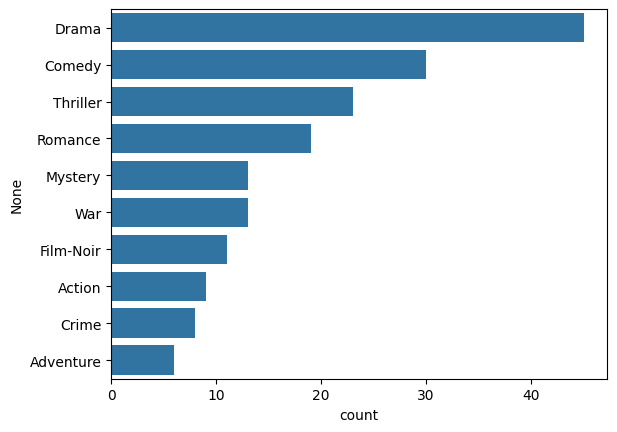

In [136]:
sns.barplot(x=female_genres_10,y=female_genres_10.index)
plt.show()

### explode 메서드

In [237]:
mfdf

,movie_id,title,genre
0,1,Toy Story (1995),"[Animation, Children's, Comedy]"
1,2,Jumanji (1995),"[Adventure, Children's, Fantasy]"
2,3,Grumpier Old Men (1995),"[Comedy, Romance]"
3,4,Waiting to Exhale (1995),"[Comedy, Drama]"
4,5,Father of the Bride Part II (1995),[Comedy]
...,...,...,...
3878,3948,Meet the Parents (2000),[Comedy]
3879,3949,Requiem for a Dream (2000),[Drama]
3880,3950,Tigerland (2000),[Drama]
3881,3951,Two Family House (2000),[Drama]


In [238]:
# movies 데이터프레임에 genre 파생변수를 추가
mfdf['genre'] = mfdf.genres.str.split('|')
mfdf

AttributeError: 'DataFrame' object has no attribute 'genres'

In [239]:
# movies 데이터프레임에서 genres 컬럼을 제거
mfdf.pop('genres') # pop() 메서드: 데이터프레임에서 컬럼을 삭제하고, 삭제한 컬럼을 리턴.

KeyError: 'genres'

In [240]:
mfdf

,movie_id,title,genre
0,1,Toy Story (1995),"[Animation, Children's, Comedy]"
1,2,Jumanji (1995),"[Adventure, Children's, Fantasy]"
2,3,Grumpier Old Men (1995),"[Comedy, Romance]"
3,4,Waiting to Exhale (1995),"[Comedy, Drama]"
4,5,Father of the Bride Part II (1995),[Comedy]
...,...,...,...
3878,3948,Meet the Parents (2000),[Comedy]
3879,3949,Requiem for a Dream (2000),[Drama]
3880,3950,Tigerland (2000),[Drama]
3881,3951,Two Family House (2000),[Drama]


In [241]:
# explode() 메서드: 컬럼이 가지고 있는 리스트의 값들을 하나씩 행(row)으로 만듦.
movies_explode=mfdf.explode('genre')

In [242]:
movies_explode

,movie_id,title,genre
0,1,Toy Story (1995),Animation
0,1,Toy Story (1995),Children's
0,1,Toy Story (1995),Comedy
1,2,Jumanji (1995),Adventure
1,2,Jumanji (1995),Children's
...,...,...,...
3879,3949,Requiem for a Dream (2000),Drama
3880,3950,Tigerland (2000),Drama
3881,3951,Two Family House (2000),Drama
3882,3952,"Contender, The (2000)",Drama


In [148]:
# movie100##################################################
movies_explode[movies_explode.title.isin(movie100)]
# movie100##################################################
movies_explode[movies_explode.title.isin(movie100)].genre.value_counts()

,movie_id,title,genre


### 남성 별점 평균 상위 100개 영화들의 장르

In [169]:
meindex=by_title_gender.sort_values(by='M',ascending=False).head(n=100).index
male_top100_movies=movies_explode[movies_explode.title.isin(meindex)]
male_top100_movies.genre.value_counts().

,count
genre,
Drama,51
Comedy,22
War,21
Thriller,19
Crime,14
Film-Noir,14
Action,13
Mystery,9
Adventure,8


In [171]:
male_genres10=male_top100_movies.genre.value_counts().head(n=10)
male_genres10

,count
genre,
Drama,51
Comedy,22
War,21
Thriller,19
Crime,14
Film-Noir,14
Action,13
Mystery,9
Adventure,8


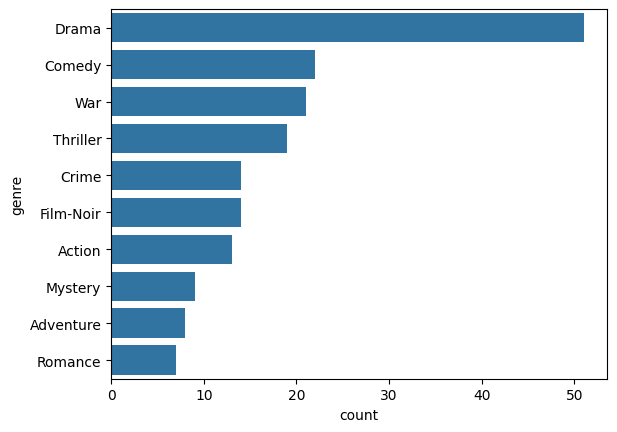

In [173]:
sns.barplot(x=male_genres10,y=male_genres10.index)
plt.show()

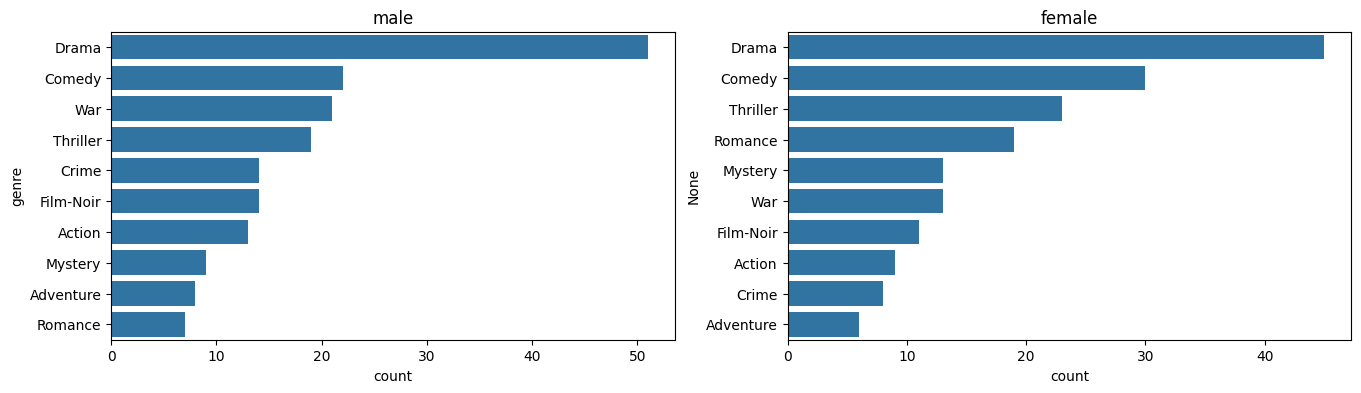

In [179]:
fig, axes =plt.subplots(nrows=1,ncols=2,figsize=(16,4))

sns.barplot(x=male_genres10,y=male_genres10.index,ax=axes[0])
sns.barplot(x=female_genres_10,y=female_genres_10.index,ax=axes[1])
axes[0].set_title('male')
axes[1].set_title('female')
plt.show()

## 호불호(선호도) 차이가 큰 영화

* 표준편차
* 120번 이상의 리뷰가 있는 영화들
* 별점의 표준편차가 큰 순서로 정렬  >>> 영화 제목, 장르
* 성별 별점의 표준편차가 큰 순서로 정렬  >>>  영화 제목, 장르

In [181]:
by_title_gender[]

gender,F,M,diff
title,,,
"'burbs, The (1989)",2.793478,2.962085,-0.168607
...And Justice for All (1979),3.828571,3.689024,0.139547
10 Things I Hate About You (1999),3.646552,3.311966,0.334586
101 Dalmatians (1961),3.791444,3.500000,0.291444
101 Dalmatians (1996),3.240000,2.911215,0.328785
...,...,...,...
Young Guns (1988),3.371795,3.425620,-0.053825
Young Guns II (1990),2.934783,2.904025,0.030758
Young Sherlock Holmes (1985),3.514706,3.363344,0.151362


In [ ]:
movies_explode[movies_explode.title.isin()]

In [157]:
male_100=by_title_gender.sort_values(by='M',ascending=False).head(n=100).index
# fem100=fem100.index
movie100=mfdf[mfdf.title.isin(male_100)]
movie100_genres=[] # 남성 별점 상위 100개 영화들의 장르들을 저장할 리스트.
for x in movie100.genres:
  movie100_genres.extend(x.split('|'))
movie100_genres
movie100_genres=pd.Series(movie100_genres) # 리스트를 시리즈로 변환 >> value_counts()메서드 이용가능
meval=movie100_genres.value_counts()
meval
# fem100=by_title_gender.sort_values(by='F',ascending=False).head(n=100)
# fem100=fem100.index
# df100=df[df.title.isin(fem100)]
# xx=df100.genres.str.split('|')
# ggenres=[]
# for x in enumerate(xx):
#   ggenres.append(x)
# ggenres

,count
Drama,51
Comedy,22
War,21
Thriller,19
Crime,14
Film-Noir,14
Action,13
Mystery,9
Adventure,8
Romance,7


In [65]:
# femcc.sort_values(ascending=False).tail(n=10)

,count
title,
EDtv (1999),94
"Adventures of Buckaroo Bonzai Across the 8th Dimension, The (1984)",94
Fly Away Home (1996),94
Serpico (1973),94
Single White Female (1992),94
"Misérables, Les (1998)",93
Something to Talk About (1995),93
Brassed Off (1996),93
Robin Hood: Prince of Thieves (1991),93


In [64]:
# mel=df[df.gender=='M']
# melc=mel.title.value_counts()
# melcc=melc[melc>=259]
# melcc.sort_values(ascending=False).head(n=10)

,count
title,
American Beauty (1999),2482
Star Wars: Episode IV - A New Hope (1977),2344
Star Wars: Episode V - The Empire Strikes Back (1980),2342
Star Wars: Episode VI - Return of the Jedi (1983),2230
Terminator 2: Judgment Day (1991),2193
Jurassic Park (1993),2099
Saving Private Ryan (1998),2078
"Matrix, The (1999)",2076
Men in Black (1997),2000


In [66]:
# melcc.sort_values(ascending=False).tail(n=10)

,count
title,
Local Hero (1983),263
Amistad (1997),263
Godzilla (Gojira) (1954),262
For Love of the Game (1999),260
Hackers (1995),260
Seven Years in Tibet (1997),260
"Man Who Would Be King, The (1975)",259
Barb Wire (1996),259
Ghost Dog: The Way of the Samurai (1999),259


In [53]:
# tc=title_count[title_count>=120]
# tc

,count
title,
American Beauty (1999),3428
Star Wars: Episode IV - A New Hope (1977),2991
Star Wars: Episode V - The Empire Strikes Back (1980),2990
Star Wars: Episode VI - Return of the Jedi (1983),2883
Jurassic Park (1993),2672
...,...
Blue Hawaii (1961),121
Backbeat (1993),120
Kazaam (1996),120


In [41]:
title_count.head(n=15)

,count
title,
American Beauty (1999),3428
Star Wars: Episode IV - A New Hope (1977),2991
Star Wars: Episode V - The Empire Strikes Back (1980),2990
Star Wars: Episode VI - Return of the Jedi (1983),2883
Jurassic Park (1993),2672
Saving Private Ryan (1998),2653
Terminator 2: Judgment Day (1991),2649
"Matrix, The (1999)",2590
Back to the Future (1985),2583


In [27]:
bottom10=rating_mean.sort_values(ascending=True).head(n=10)
bottom10

,rating
title,
Windows (1980),1.0
Wirey Spindell (1999),1.0
Torso (Corpi Presentano Tracce di Violenza Carnale) (1973),1.0
Kestrel's Eye (Falkens öga) (1998),1.0
Terror in a Texas Town (1958),1.0
Santa with Muscles (1996),1.0
"Silence of the Palace, The (Saimt el Qusur) (1994)",1.0
"Low Life, The (1994)",1.0
Even Dwarfs Started Small (Auch Zwerge haben klein angefangen) (1971),1.0


In [28]:
# rating_mean[rating_mean[['title','rating']]==1].unique()


In [29]:
# top10_titles = top10.index

# df[df['title'].isin(top10_titles)]

,user_id,movie_id,rating,timestamp,title,genres,gender,age,occupation,zip_code
6448,46,3280,5,977979487,"Baby, The (1973)",Horror,M,18,19,75602
19836,149,787,5,977325719,"Gate of Heavenly Peace, The (1995)",Documentary,M,25,1,29205
21627,157,2905,4,977248885,Sanjuro (1962),Action|Adventure,M,35,16,12866
24445,173,2905,5,990547917,Sanjuro (1962),Action|Adventure,M,25,0,45237
28032,195,3245,5,1025023134,I Am Cuba (Soy Cuba/Ya Kuba) (1964),Drama,M,25,12,10458
...,...,...,...,...,...,...,...,...,...,...
988671,5968,2905,5,956963858,Sanjuro (1962),Action|Adventure,M,56,7,98103
990716,5981,2905,4,956930870,Sanjuro (1962),Action|Adventure,M,35,7,01776
996190,6016,2503,4,956958948,"Apple, The (Sib) (1998)",Drama,M,45,1,37209
996467,6016,3245,5,994453507,I Am Cuba (Soy Cuba/Ya Kuba) (1964),Drama,M,45,1,37209


In [30]:
# bottom10_title=bottom10.index
# df[df['title'].isin(bottom10_title)]

,user_id,movie_id,rating,timestamp,title,genres,gender,age,occupation,zip_code
8684,58,1311,1,977936528,Santa with Muscles (1996),Comedy,M,25,2,30303
27669,193,1311,1,977018841,Santa with Muscles (1996),Comedy,F,45,15,44106
90645,601,1311,1,975882621,Santa with Muscles (1996),Comedy,F,18,20,06320
168187,1069,730,1,974943274,"Low Life, The (1994)",Drama,M,25,20,98105
201369,1242,3228,1,987709390,Wirey Spindell (1999),Comedy,F,35,0,10014
243858,1470,3493,1,974836920,Torso (Corpi Presentano Tracce di Violenza Car...,Horror,M,18,4,94118
244026,1470,1386,1,974836379,Terror in a Texas Town (1958),Western,M,18,4,94118
245135,1478,1311,1,974752662,Santa with Muscles (1996),Comedy,M,1,10,92620
287002,1713,684,1,974705435,Windows (1980),Drama,M,25,0,47421
329308,1943,1311,1,993575910,Santa with Muscles (1996),Comedy,M,18,4,91501


In [192]:
# df_reduced.groupby(by='title').rating.std().sort_values(ascending=False)

,rating
title,
Plan 9 from Outer Space (1958),1.455998
Godzilla 2000 (Gojira ni-sen mireniamu) (1999),1.364700
"Texas Chainsaw Massacre, The (1974)",1.332448
Dumb & Dumber (1994),1.321333
Crash (1996),1.319636
...,...
"Wrong Trousers, The (1993)",0.708666
"Shawshank Redemption, The (1994)",0.700443
"Great Escape, The (1963)",0.692585


In [230]:
# df_reduced=df[df.title.isin(indexer)]
# df_reduced.groupby(by=['title','genres']).rating.std().sort_values(ascending=False)
by_title_gender=df_reduced.pivot_table(values='rating',index=['title','genres'],columns='gender',aggfunc='std')
by_title_gender.sort_values(by='M',ascending=False)

,gender,F,M
title,genres,,
Plan 9 from Outer Space (1958),Horror|Sci-Fi,1.400348,1.467654
Godzilla 2000 (Gojira ni-sen mireniamu) (1999),Action|Adventure|Sci-Fi,1.377733,1.345558
Dancer in the Dark (2000),Drama|Musical,1.042633,1.320187
"Blair Witch Project, The (1999)",Horror,1.313929,1.317775
"Texas Chainsaw Massacre, The (1974)",Horror,1.401530,1.316664
...,...,...,...
Raiders of the Lost Ark (1981),Action|Adventure,0.792796,0.699111
Rear Window (1954),Mystery|Thriller,0.671284,0.696009
"Shawshank Redemption, The (1994)",Drama,0.719194,0.693091


### 제목별 별점 표준편차

In [233]:
std_by_title=df_reduced.pivot_table(values='rating',index='title',aggfunc='std')
std_by_title

,rating
title,
"'burbs, The (1989)",1.107760
...And Justice for All (1979),0.878110
10 Things I Hate About You (1999),0.989815
101 Dalmatians (1961),0.982103
101 Dalmatians (1996),1.098717
...,...
Young Guns (1988),1.017437
Young Guns II (1990),1.071959
Young Sherlock Holmes (1985),0.891176


In [245]:
# std_by_title.sort_values(by='rating',ascending=False).head(n=100)
sbt100=std_by_title.sort_values(by='rating',ascending=False).head(n=100).index
movies_explode[movies_explode.title.isin(sbt100)].genre.value_counts()

,count
genre,
Comedy,45
Horror,28
Drama,25
Action,17
Sci-Fi,14
Thriller,11
Children's,9
Animation,7
War,6


### 제목별 성별 별점 표준편차

In [247]:
std_by_title_gender=df_reduced.pivot_table(values='rating',index='title',columns='gender',aggfunc='std')
std_by_title_gender

gender,F,M
title,,
"'burbs, The (1989)",1.124532,1.099127
...And Justice for All (1979),0.954424,0.862086
10 Things I Hate About You (1999),0.986965,0.973364
101 Dalmatians (1961),0.882525,1.015137
101 Dalmatians (1996),1.072412,1.099110
...,...,...
Young Guns (1988),0.884337,1.037917
Young Guns II (1990),1.062537,1.074875
Young Sherlock Holmes (1985),0.889284,0.890709


In [249]:
# 여성 별점 표준편차 내림차순 정렬
std_by_title_gender.sort_values(by='F',ascending=False)


gender,F,M
title,,
"Specialist, The (1994)",1.589803,1.160106
"Transformers: The Movie, The (1986)",1.558387,1.255736
Home Alone 3 (1997),1.556735,0.934488
"Thing From Another World, The (1951)",1.504894,1.024437
"Postman, The (1997)",1.497776,1.242966
...,...,...
Kazaam (1996),0.615699,0.829003
Mortal Kombat: Annihilation (1997),0.611250,1.140053
Wallace & Gromit: The Best of Aardman Animation (1996),0.605043,0.853533


In [252]:
# 여성 별점 표준 편차가 큰 영화 제목 100개
sft100=std_by_title_gender.sort_values(by='F',ascending=False).head(n=100).index
sft100

Index(['Specialist, The (1994)', 'Transformers: The Movie, The (1986)',
       'Home Alone 3 (1997)', 'Thing From Another World, The (1951)',
       'Postman, The (1997)', 'Surviving the Game (1994)', 'Wishmaster (1997)',
       'Near Dark (1987)', 'Children of the Damned (1963)',
       'Hard Target (1993)', 'Ravenous (1999)',
       'Cook the Thief His Wife & Her Lover, The (1989)',
       'Armed and Dangerous (1986)', 'Bride of Chucky (1998)',
       'McHale's Navy (1997)', 'Texas Chainsaw Massacre, The (1974)',
       'Plan 9 from Outer Space (1958)', 'Puppet Master (1989)',
       'Godzilla 2000 (Gojira ni-sen mireniamu) (1999)', 'Soldier (1998)',
       'South Park: Bigger, Longer and Uncut (1999)', 'Idle Hands (1999)',
       'Adventures of Rocky and Bullwinkle, The (2000)', 'Cube (1997)',
       'Nightmare on Elm Street, A (1984)', 'Cutthroat Island (1995)',
       'Pink Flamingos (1972)', 'BASEketball (1998)',
       'Natural Born Killers (1994)', 'Dumb & Dumber (1994)',
     

In [255]:
# 여성 별점 표준편차가 큰 영화 100개의 장르
# movies_explode[movies_explode.title.isin(sft100)]
movies_explode[movies_explode.title.isin(sft100)].genre.value_counts()

,count
genre,
Comedy,39
Horror,35
Sci-Fi,25
Action,23
Thriller,21
Adventure,13
Drama,13
Children's,10
Crime,8


In [257]:
# 남성 별점 표준편차 내림차순 정렬
std_by_title_gender.sort_values(by='M',ascending=False)

gender,F,M
title,,
Plan 9 from Outer Space (1958),1.400348,1.467654
Godzilla 2000 (Gojira ni-sen mireniamu) (1999),1.377733,1.345558
Dancer in the Dark (2000),1.042633,1.320187
"Blair Witch Project, The (1999)",1.313929,1.317775
"Texas Chainsaw Massacre, The (1974)",1.401530,1.316664
...,...,...
Raiders of the Lost Ark (1981),0.792796,0.699111
Rear Window (1954),0.671284,0.696009
"Shawshank Redemption, The (1994)",0.719194,0.693091


In [260]:
# 남성 별점 표준편차가 큰 영화 100개의 제목
smti100=std_by_title_gender.sort_values(by='M',ascending=False).head(n=100).index


In [261]:
# 남성 별점 표준편차가 큰 영화 100개의 장르
movies_explode[movies_explode.title.isin(smti100)].genre.value_counts()

,count
genre,
Comedy,48
Drama,29
Horror,24
Action,15
Sci-Fi,15
Children's,11
Thriller,11
Romance,7
Animation,6


## TODO
e-mail
*   리뷰 개수가 (중위값 >> 평균값) 250개 이상인 영화들 선택
*   별점 평균이 4.0 이상인 영화들의 장르
    *   성별 별점 평균이 4.0 이상인 영화들의 장르
*   연령대별 별점 평균이 높은 순서로 정렬 --> 장르
*   장르별 별점 평균 순위    